In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
# Đường dẫn tới file sales
file_path = "/home/vietha/MOIC/MOIC_Inventory/data/raw/SCTBH.csv"

#Tạo dataframe sales
sales = pd.read_csv(file_path)

/tmp/ipykernel_50306/1486233159.py:5: DtypeWarning: Columns (0: Stt) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv(file_path)


In [18]:
sales.head()

,Ngày,Stt,SalesNumber,Mã hàng,Quantity,UnitPrice,SalesAmount,Unit Cost,Cost Amount,Mã KH,Bravo
0,1/3/2022,1339552,HT030122-001,48341-47010,2,240000.0,480000,215000.00,430000.0,DUCMANH-TM,HT
1,1/3/2022,1339552,HT030122-001,T24ZE121B,2,130000.0,260000,77679.14,155358.0,DUCMANH-TM,HT
2,1/3/2022,1339552,HT030122-001,T24ZE121S,2,90000.0,180000,47383.67,94767.0,DUCMANH-TM,HT
3,1/3/2022,1339553,HT030122-002,DTX-162A,1,714286.0,700000,548265.89,548266.0,CONGNGHED6VD-TM,HT
4,1/3/2022,1339553,HT030122-002,CTX-065A,1,816326.0,799999,615591.67,615592.0,CONGNGHED6VD-TM,HT


In [19]:
import numpy as np

# --- 0. Đảm bảo cột Ngày là datetime ---
sales['Ngày'] = pd.to_datetime(
    sales['Ngày'].astype(str).str.strip(),
    format='%m/%d/%Y',
    errors='coerce'
)
# --- 1. Tổng SalesAmount theo Mã hàng (giữ code gốc của bạn) ---
total_by_product = (
    sales.groupby('Mã hàng', dropna=False)['SalesAmount']
         .sum()
         .reset_index()
)
total_by_product = total_by_product.rename(columns={'SalesAmount': 'TotalSalesAmount'})

# Sắp xếp giảm dần và lọc lớn hơn 0
total_by_product = total_by_product.sort_values('TotalSalesAmount', ascending=False)
total_by_product = total_by_product[total_by_product['TotalSalesAmount'] > 0]

# --- 2. Tính ADI & CV² theo Croston/Syntetos–Boylan ---

# Trước tiên gom demand theo ngày cho từng mã hàng
daily_sales = (
    sales.groupby(['Mã hàng', 'Ngày'], as_index=False)['Quantity']
         .sum()
         .rename(columns={'Quantity': 'DailyQty'})
)

def sbc_features(group):
    """
    group: dữ liệu daily của 1 'Mã hàng'
    Trả về: ADI (Average Inter-demand Interval) và CV²
    """
    g = group.sort_values('Ngày')  # sắp xếp theo thời gian
    qty = g['DailyQty'].to_numpy()

    # Những ngày có demand > 0 (thường là tất cả, nhưng cứ check cho chắc)
    nz_mask = qty > 0
    if nz_mask.sum() == 0:
        # Không có bán
        adi = np.inf
        cv2 = 0.0
    else:
        # Khoảng cách ngày giữa các lần có bán (>0)
        nz_dates = g.loc[nz_mask, 'Ngày']
        gaps = nz_dates.diff().dt.days.dropna()

        if gaps.empty:
            # Chỉ có 1 lần bán → không đo được khoảng cách, tạm cho ADI = 1
            adi = 1.0
        else:
            adi = gaps.mean()

        sizes = qty[nz_mask]
        mean_size = sizes.mean()
        if mean_size == 0 or len(sizes) == 1:
            cv2 = 0.0
        else:
            cv = sizes.std(ddof=0) / mean_size
            cv2 = cv ** 2

    return pd.Series({'ADI': adi, 'CV2': cv2})

item_stats = (
    daily_sales
    .groupby('Mã hàng', as_index=False)
    .apply(sbc_features)
    .reset_index(drop=True)
)

# --- 3. Phân loại 4 dạng cầu ---

def classify_demand(row):
    adi = row['ADI']
    cv2 = row['CV2']
    if adi <= 1.32 and cv2 <= 0.49:
        return 'smooth'
    elif adi <= 1.32 and cv2 > 0.49:
        return 'erratic'
    elif adi > 1.32 and cv2 <= 0.49:
        return 'intermittent'
    else:
        return 'lumpy'

item_stats['demand_type'] = item_stats.apply(classify_demand, axis=1)

# --- 4. Gộp vào bảng total_by_product ---
total_by_product = total_by_product.merge(
    item_stats[['Mã hàng', 'ADI', 'CV2', 'demand_type']],
    on='Mã hàng',
    how='left'
)

# Xem thử
total_by_product.head()

,Mã hàng,TotalSalesAmount,ADI,CV2,demand_type
0,.HT-HD-HT,17600049249,1.274886,0.494286,erratic
1,9047,10081348060,15.481481,1.749479,lumpy
2,JK272000-6900,9461720773,1.395604,11.698024,lumpy
3,.HT-HD-BW,8229817221,1.501622,0.573272,lumpy
4,90919-T1002,6254631160,1.352372,6.857622,lumpy


In [20]:
total_by_product

,Mã hàng,TotalSalesAmount,ADI,CV2,demand_type
0,.HT-HD-HT,17600049249,1.274886,0.494286,erratic
1,9047,10081348060,15.481481,1.749479,lumpy
2,JK272000-6900,9461720773,1.395604,11.698024,lumpy
3,.HT-HD-BW,8229817221,1.501622,0.573272,lumpy
4,90919-T1002,6254631160,1.352372,6.857622,lumpy
...,...,...,...,...,...
15629,HT-04445-17287,10000,1.000000,0.000000,smooth
15630,HT-04445-15246,10000,1.000000,0.000000,smooth
15631,HT-04445-15355,10000,1.000000,0.000000,smooth
15632,GHIT7-12-10,6000,1.000000,0.000000,smooth


Trực quan hoá về phân bổ cầu

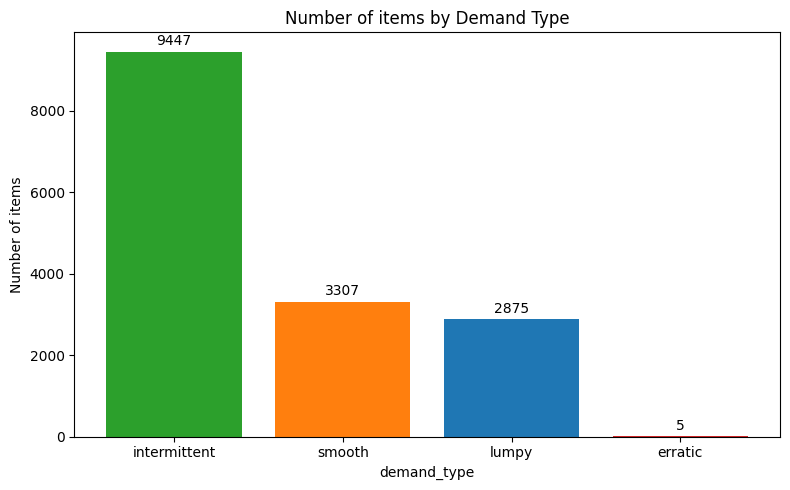

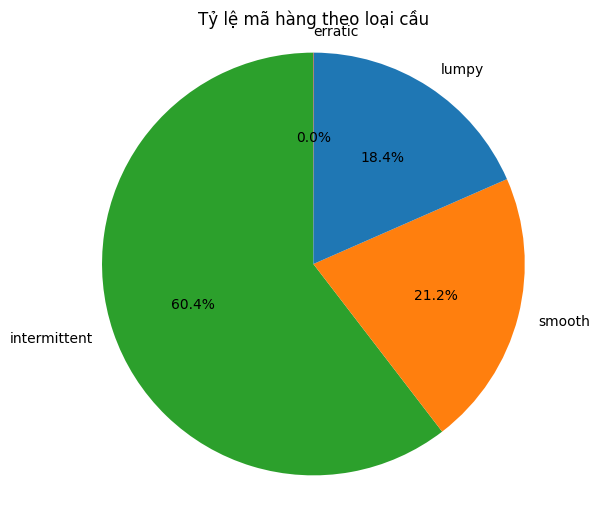

In [21]:
# Đếm số lượng mã hàng theo demand_type (gộp NaN thành 'unknown')
demand_counts = total_by_product['demand_type'].fillna('unknown').value_counts()

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(demand_counts.index, demand_counts.values, color=['tab:green', 'tab:orange', 'tab:blue', 'tab:red', 'gray'])
ax.set_title('Number of items by Demand Type')
ax.set_ylabel('Number of items')
ax.set_xlabel('demand_type')

# Add value labels on bars
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + max(demand_counts.values) * 0.01, f'{int(h)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Pie chart (tỷ lệ)
fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.pie(demand_counts.values, labels=demand_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['tab:green', 'tab:orange', 'tab:blue', 'tab:red', 'gray'])
ax2.set_title('Tỷ lệ mã hàng theo loại cầu')
ax2.axis('equal')
plt.show()

Thực hiện K mean

Cluster sizes (numeric labels):
0    3545
1    5184
2    6905

Cluster centers (original scale): [80710163.11712714   699583.6164967   6758786.98926098]

ABC class sizes:
ABC_class
B    6905
C    5184
A    3545


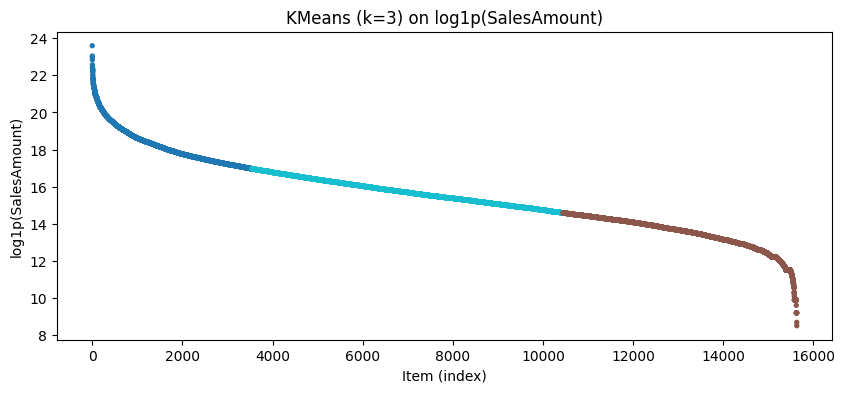

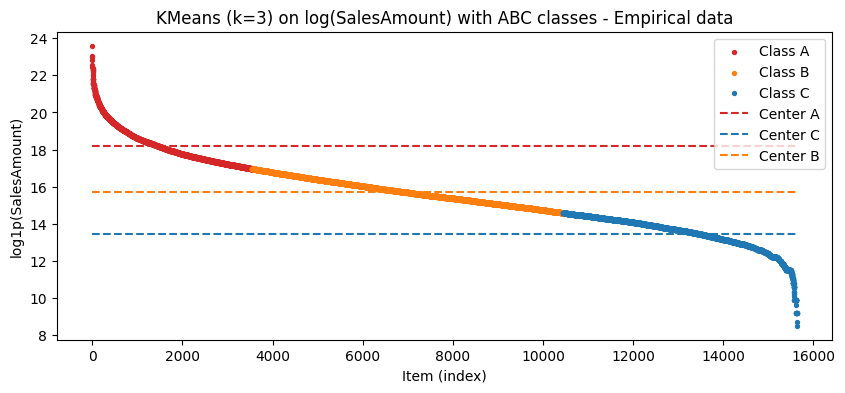

In [22]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Prepare data (log transform to reduce skew)
X_for_clust = np.log1p(total_by_product['TotalSalesAmount'].values).reshape(-1, 1)

# Fit KMeans k=3
km3 = KMeans(n_clusters=3, n_init=10, random_state=42)
labels3 = km3.fit_predict(X_for_clust)

# ---- GÁN NHÃN ABC DỰA TRÊN TRUNG TÂM CỤM ----
# Trung tâm cụm ở log-scale
centers_log = km3.cluster_centers_.ravel()
# Đưa về scale gốc
centers_orig = np.expm1(centers_log)

# Sắp xếp cụm theo giá trị trung tâm tăng dần
# order[0] = cụm nhỏ nhất, order[2] = cụm lớn nhất
order = np.argsort(centers_orig)

# Map: nhỏ nhất -> C, trung bình -> B, lớn nhất -> A
cluster_to_abc = {
    order[0]: 'C',
    order[1]: 'B',
    order[2]: 'A'
}

# Lưu cả nhãn số và nhãn ABC
total_by_product['cluster_3'] = labels3
total_by_product['ABC_class'] = [cluster_to_abc[c] for c in labels3]

# In thông tin
print("Cluster sizes (numeric labels):")
print(pd.Series(labels3).value_counts().sort_index().to_string())
print("\nCluster centers (original scale):", centers_orig)

print("\nABC class sizes:")
print(total_by_product['ABC_class'].value_counts().to_string())

# ---- Scatter plot log-sales theo cụm số ----
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(np.arange(len(total_by_product)), X_for_clust.ravel(), c=labels3, cmap='tab10', s=8)
ax.set_xlabel('Item (index)')
ax.set_ylabel('log1p(SalesAmount)')
ax.set_title('KMeans (k=3) on log1p(SalesAmount)')

# --- Scatter plot log-sales theo ABC class ---
fig, ax = plt.subplots(figsize=(10, 4))

# Tạo mảng nhãn ABC tương ứng từng item
abc_labels = total_by_product['ABC_class'].values

# Định nghĩa màu cho từng lớp
color_map = {'A': 'tab:red', 'B': 'tab:orange', 'C': 'tab:blue'}

# Vẽ từng lớp A/B/C riêng để có legend rõ ràng
x_idx = np.arange(len(total_by_product))
for cls in ['A', 'B', 'C']:
    mask = (abc_labels == cls)
    ax.scatter(
        x_idx[mask],
        X_for_clust.ravel()[mask],
        s=8,
        label=f'Class {cls}',
        color=color_map[cls]
    )

ax.set_xlabel('Item (index)')
ax.set_ylabel('log1p(SalesAmount)')
ax.set_title('KMeans (k=3) on log(SalesAmount) with ABC classes - Empirical data')

# Vẽ đường ngang tại trung tâm cụm, gắn nhãn A/B/C
for clust_id, center_log in enumerate(centers_log):
    abc = cluster_to_abc[clust_id]
    ax.hlines(
        center_log,
        xmin=0,
        xmax=len(total_by_product) - 1,
        colors=color_map[abc],
        linestyles='--',
        label=f'Center {abc}'
    )

ax.legend()
plt.show()


In [23]:
total_by_product

,Mã hàng,TotalSalesAmount,ADI,CV2,demand_type,cluster_3,ABC_class
0,.HT-HD-HT,17600049249,1.274886,0.494286,erratic,0,A
1,9047,10081348060,15.481481,1.749479,lumpy,0,A
2,JK272000-6900,9461720773,1.395604,11.698024,lumpy,0,A
3,.HT-HD-BW,8229817221,1.501622,0.573272,lumpy,0,A
4,90919-T1002,6254631160,1.352372,6.857622,lumpy,0,A
...,...,...,...,...,...,...,...
15629,HT-04445-17287,10000,1.000000,0.000000,smooth,1,C
15630,HT-04445-15246,10000,1.000000,0.000000,smooth,1,C
15631,HT-04445-15355,10000,1.000000,0.000000,smooth,1,C
15632,GHIT7-12-10,6000,1.000000,0.000000,smooth,1,C


In [24]:
# Thêm cột 'year' (và 'years' nếu muốn) từ cột 'Ngày'
sales['year'] = sales['Ngày'].dt.year

# Kiểm tra nhanh
sales[['Ngày', 'year']].head()

,Ngày,year
0,2022-01-03,2022
1,2022-01-03,2022
2,2022-01-03,2022
3,2022-01-03,2022
4,2022-01-03,2022


In [25]:
import numpy as np
import pandas as pd

# Tổng doanh số theo Mã hàng & năm
annual_sales = (sales
                .groupby(['Mã hàng', 'year'], as_index=False)['SalesAmount']
                .sum()
                .rename(columns={'SalesAmount': 'annual_sales'}))

# Sắp xếp để tính % change đúng thứ tự thời gian
annual_sales = annual_sales.sort_values(['Mã hàng', 'year'])

# % thay đổi doanh số năm (so với năm trước), tính theo %
annual_sales['pct_change'] = (
    annual_sales
    .groupby('Mã hàng')['annual_sales']
    .pct_change() * 100
)

annual_sales['last_annual_sales'] = (
    annual_sales
    .groupby('Mã hàng')['annual_sales']
    .shift(1)     # lấy giá trị năm trước
)

# Năm đầu tiên mà item phát sinh sales > 0
first_year = (
    annual_sales.loc[annual_sales['annual_sales'] > 0]
    .groupby('Mã hàng')['year']
    .min()
)

annual_sales['first_sales_year'] = annual_sales['Mã hàng'].map(first_year)


# Làm sạch pct_change
pct = (annual_sales['pct_change']
       .replace([np.inf, -np.inf], np.nan)
       .dropna())

# Tính quantile làm ranh giới lifecycle
quints = pct.quantile([0.2, 0.4, 0.6, 0.8])

Q20 = quints.loc[0.2]
Q40 = quints.loc[0.4]
Q60 = quints.loc[0.6]
Q80 = quints.loc[0.8]

print("Q20 =", Q20)
print("Q40 =", Q40)
print("Q60 =", Q60)
print("Q80 =", Q80)

def classify_stage(row):
    sales = row['annual_sales']
    pct   = row['pct_change']
    year  = row['year']
    first_year = row['first_sales_year']
    last_sales = row['last_annual_sales']

    # Introduction: chỉ năm đầu tiên có sales
    if year == first_year:
        return 'Introduction'

    # Phase out: năm trước không có sales hoặc pct không xác định
    if last_sales == 0 or pd.isna(pct):
        return 'Phase out'

    # ===== PHÂN LOẠI HOÀN TOÀN THEO 5 QUANTILE =====
    if pct <= Q20:
        return 'Decline'
    elif Q20 < pct <= -5:
        return 'Decaying maturity'
    elif -5 < pct <= 5:
        return 'Stable maturity'
    elif 5 < pct <= Q80:
        return 'Sustained maturity'
    elif pct > Q80:
        return 'Growth'
    else:
        return 'Unknown'


annual_sales['life_cycle_stage'] = annual_sales.apply(classify_stage, axis=1)
annual_sales.head(5)

Q20 = -59.5038319481094
Q40 = -30.038461538461537
Q60 = 2.5210084033613356
Q80 = 81.4721500319654


,Mã hàng,year,annual_sales,pct_change,last_annual_sales,first_sales_year,life_cycle_stage
0,.HT-HD-ASP,2025,36084333,NaN,NaN,2025.0,Introduction
1,.HT-HD-BW,2022,1361770873,NaN,NaN,2022.0,Introduction
2,.HT-HD-BW,2023,2315105211,70.006956,1.361771e+09,2022.0,Sustained maturity
3,.HT-HD-BW,2024,2047358711,-11.565198,2.315105e+09,2022.0,Decaying maturity
4,.HT-HD-BW,2025,2505582426,22.381213,2.047359e+09,2022.0,Sustained maturity


<Axes: title={'center': 'Number of items by Life Cycle Stage(as of 2025)'}, xlabel='life_cycle_stage'>

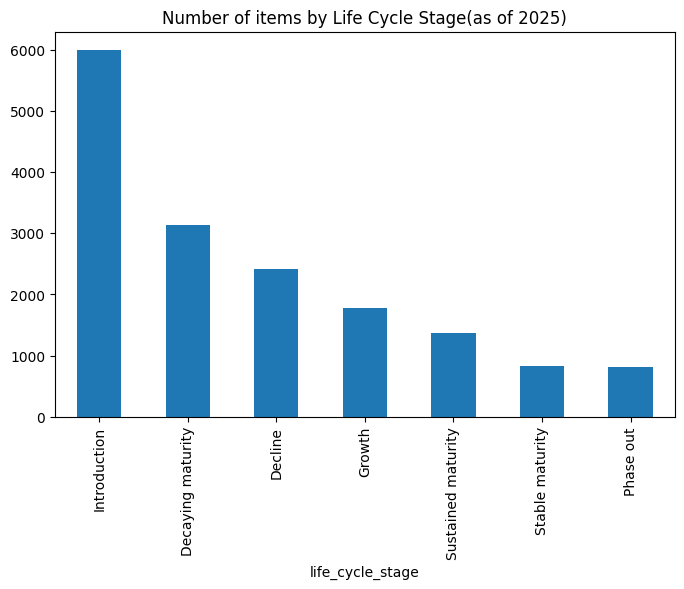

In [26]:
current_stage_by_item = (annual_sales[annual_sales['year'] <= 2025]
                         .sort_values(['Mã hàng', 'year'])
                         .groupby('Mã hàng')
                         .tail(1)
                         .reset_index(drop=True))

current_stage_by_item.value_counts('life_cycle_stage').plot(kind='bar', figsize=(8,5), title='Number of items by Life Cycle Stage(as of 2025)')

In [27]:
current_stage_by_item[current_stage_by_item['life_cycle_stage'] == "Introduction"]

,Mã hàng,year,annual_sales,pct_change,last_annual_sales,first_sales_year,life_cycle_stage
0,.HT-HD-ASP,2025,36084333,NaN,NaN,2025.0,Introduction
8,0-121,2022,2015071,NaN,NaN,2022.0,Introduction
10,01463-T0A-A00-A,2022,140000,NaN,NaN,2022.0,Introduction
11,016-060-0017HD,2022,378280,NaN,NaN,2022.0,Introduction
12,016-060-0018HD,2022,388080,NaN,NaN,2022.0,Introduction
...,...,...,...,...,...,...,...
16325,ZL01-10-235-WTA-CC,2024,304560,NaN,NaN,2024.0,Introduction
16328,ZL01-18-140A-CC,2025,700000,NaN,NaN,2025.0,Introduction
16329,ZL01-18-221A,2022,1450000,NaN,NaN,2022.0,Introduction
16330,ZL05-20-490A,2022,774000,NaN,NaN,2022.0,Introduction


In [28]:
product = pd.read_csv('DataRaw\DMVT.csv')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_50306/3967541766.py:1: SyntaxWarning: invalid escape sequence '\D'
  product = pd.read_csv('DataRaw\DMVT.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'DataRaw\\DMVT.csv'

In [ ]:
# Dict mapping từ BCG mã sang Product Life Cycle
bcg_to_cycle = {
    "SUPER_XA": "Decline",
    "Hang_dang_phat_trien": "Introduction",
    "Nhap_tam_du_ban": "Decaying maturity",
    "Hang_duy_tri": "Stable maturity",
    "Hangpheu": "Growth/Sustained maturity",
    "Hang_xa&Nhap_tam_du_ban": "Decline",
    "Hangpheu_Lnthap": "Growth/Sustained maturity"
}

# Thêm cột ProductCycle2 dựa vào cột 'Phân loại BCG mã'
product["ProductCycle2"] = product["Phân loại BCG mã "].map(bcg_to_cycle)

# Nếu muốn gán 'Unknown' cho các mã không có trong dict:
# product["ProductCycle2"] = product["Phân loại BCG mã"].map(bcg_to_cycle).fillna("Unknown")


<Axes: title={'center': 'Product Cycle Stage by Expert Classification'}, xlabel='ProductCycle2'>

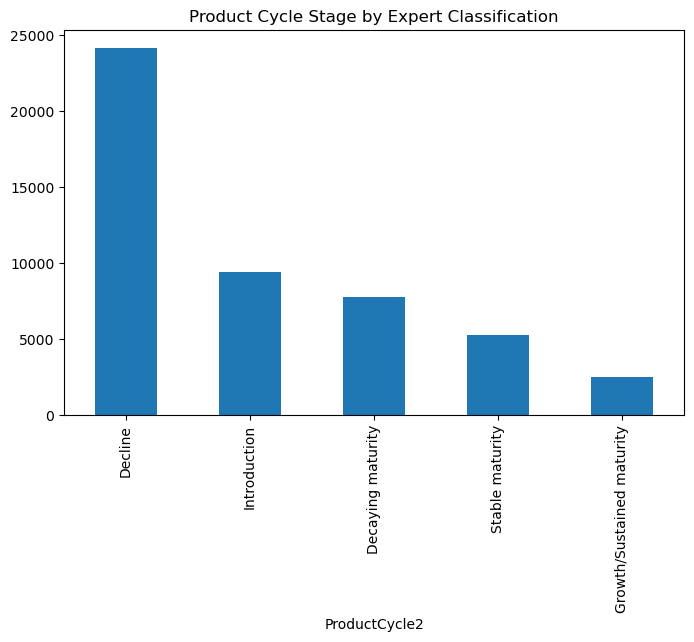

In [ ]:
product['ProductCycle2'].value_counts().plot(kind='bar', figsize=(8,5), title='Product Cycle Stage by Expert Classification')

19876 18007


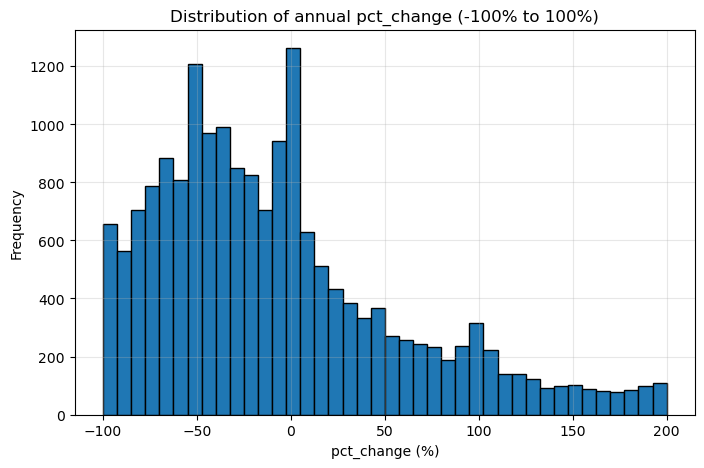

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Làm sạch pct_change
pct = (annual_sales['pct_change']
       .replace([np.inf, -np.inf], np.nan)
       .dropna())

# 2. Chỉ xem những quan sát trong khoảng -100% đến +100%
pct_clip = pct[pct.between(-100, 200)]

print(len(pct), len(pct_clip))  # xem còn bao nhiêu điểm sau khi cắt

plt.figure(figsize=(8, 5))
plt.hist(pct_clip, bins=40, edgecolor='black')  # 40 bins cho mượt
plt.xlabel('pct_change (%)')
plt.ylabel('Frequency')
plt.title('Distribution of annual pct_change (-100% to 100%)')
plt.grid(alpha=0.3)
plt.show()